# Minor Project 3: Airbnb Price Prediction Using Linear Regression

## Student Details

**Name:** Ansh Arora
**Project Title:** Minor Project 3

---

## Project Overview

The objective of this project is to build a Linear Regression model capable of predicting the price of Airbnb listings in New York City based on listing characteristics such as room type, location, availability, reviews, and minimum nights.

The project follows a complete Machine Learning workflow including:

1. Data Loading and Inspection
2. Exploratory Data Analysis (EDA)
3. Missing Value Handling
4. Outlier Detection and Treatment
5. Feature Selection
6. Feature Encoding
7. Train-Test Split
8. Linear Regression Model Building
9. Model Evaluation
10. Residual Analysis and Interpretation

---

## Dataset Information

**Dataset Name:** New York City Airbnb Open Data (2019)

**Dataset Source:**
https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

**File Used:**
AB_NYC_2019.csv

---

## Dataset Description

The dataset contains information about Airbnb listings in New York City during 2019.

### Number of Records

48,895 Listings

### Number of Features

16 Columns

### Target Variable

**price**

The objective of the model is to predict the listing price using the remaining features.

### Important Features

* neighbourhood_group
* neighbourhood
* room_type
* minimum_nights
* number_of_reviews
* reviews_per_month
* calculated_host_listings_count
* availability_365
* latitude
* longitude

---

## Machine Learning Technique Used

Linear Regression

Linear Regression is a supervised machine learning algorithm used to model the relationship between a dependent variable (price) and one or more independent variables.

---

## Expected Outcome

The final model predicts Airbnb listing prices and evaluates performance using:

* R² Score
* Mean Absolute Error (MAE)
* Root Mean Squared Error (RMSE)

Residual analysis is also performed to assess model performance and identify prediction patterns.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (48895, 16)


In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include="object").columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='str')

Categorical Columns:
Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review'],
      dtype='str')


C:\Users\ansha\AppData\Local\Temp\ipykernel_22568\4129928474.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [9]:
for col in categorical_cols: print(f"\n{col}") 
print("Unique Values:", df[col].nunique())


name

host_name

neighbourhood_group

neighbourhood

room_type

last_review
Unique Values: 1764


In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [11]:
missing_percentage = (
    df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

In [12]:
missing_df = pd.DataFrame({ 
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_df.sort_values(by="Percentage",ascending=False)

,Missing Values,Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [13]:
df["last_review"].head()

0    2018-10-19
1    2019-05-21
2           NaN
3    2019-07-05
4    2018-11-19
Name: last_review, dtype: str

In [14]:
df.drop(
    columns=["last_review"],
    inplace=True
)

In [15]:
df["reviews_per_month"] = (
    df["reviews_per_month"]
    .fillna(0)
)

In [16]:
columns_to_drop = [
    "id",
    "host_id",
    "name",
    "host_name"
]

df.drop(
    columns=columns_to_drop,
    inplace=True
)

In [17]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [18]:
print("Before Outlier Removal:")
print(df.shape)

Before Outlier Removal:
(48895, 11)


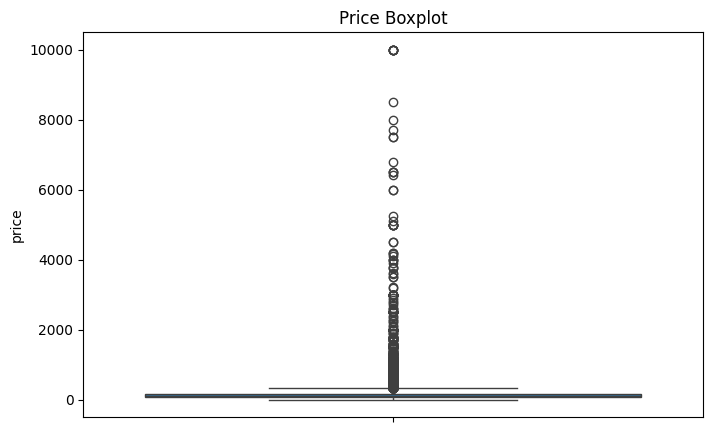

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["price"]
)

plt.title("Price Boxplot")
plt.show()

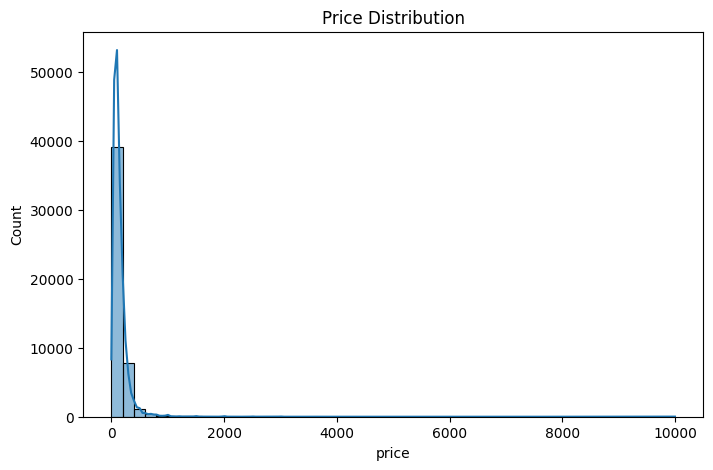

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=50,
    kde=True
)

plt.title("Price Distribution")
plt.show()

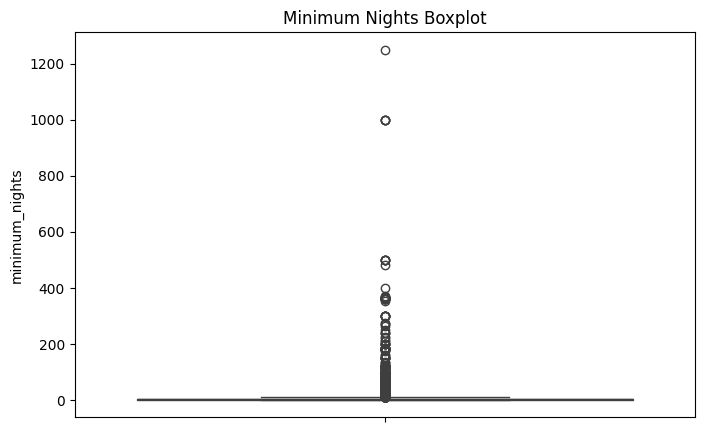

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["minimum_nights"]
)

plt.title("Minimum Nights Boxplot")
plt.show()

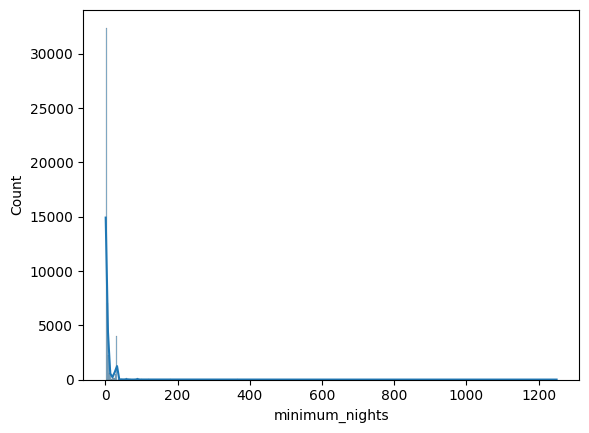

In [22]:
sns.histplot(df["minimum_nights"], kde=True)
plt.show()

In [23]:
price_limit = (
    df["price"]
    .quantile(0.95)
)

print(price_limit)

355.0


In [24]:
df = df[
    df["price"] <= price_limit
]

In [25]:
night_limit = (
    df["minimum_nights"]
    .quantile(0.95)
)

print(night_limit)

30.0


In [26]:
df = df[
    df["minimum_nights"]
    <= night_limit
]

In [27]:
print(df.shape)

(45759, 11)


In [28]:
print("After Outlier Removal:")
print(df.shape)

After Outlier Removal:
(45759, 11)


In [29]:
df["neighbourhood"].nunique()

219

In [30]:
df.drop(
    columns=["neighbourhood"],
    inplace=True
)

In [31]:
df = pd.get_dummies(
    df,
    columns=[
        "neighbourhood_group",
        "room_type"
    ],
    drop_first=True
)

In [32]:
df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,True,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.00,1,365,False,True,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,True,False,False,False,False


In [33]:
df.info()

<class 'pandas.DataFrame'>
Index: 45759 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           45759 non-null  float64
 1   longitude                          45759 non-null  float64
 2   price                              45759 non-null  int64  
 3   minimum_nights                     45759 non-null  int64  
 4   number_of_reviews                  45759 non-null  int64  
 5   reviews_per_month                  45759 non-null  float64
 6   calculated_host_listings_count     45759 non-null  int64  
 7   availability_365                   45759 non-null  int64  
 8   neighbourhood_group_Brooklyn       45759 non-null  bool   
 9   neighbourhood_group_Manhattan      45759 non-null  bool   
 10  neighbourhood_group_Queens         45759 non-null  bool   
 11  neighbourhood_group_Staten Island  45759 non-null  bool   
 12  room_t

In [37]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='str')


In [34]:
X = df.drop(
    "price",
    axis=1
)

y = df["price"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(36607, 13)
(9152, 13)
(36607,)
(9152,)


In [39]:
model = LinearRegression()

In [40]:
model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ -74.78,-290.08, -1.07,..., -84.1 , -79.98,-105.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['latitude','longitude','minimum_nights',..., 'neighbourhood_group_Staten Island','room_type_Private room', 'room_type_Shared room']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.825e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,13


In [41]:
X = df.drop(
    "price",
    axis=1
)

y = df["price"]

In [42]:
y_pred = model.predict(X_test)

In [43]:
r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("R2 Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("RMSE     :", round(rmse,2))

R2 Score : 0.4708
MAE      : 38.54
RMSE     : 53.24


In [44]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
15403,132,173.319992
25339,250,157.350885
17177,350,173.114638
39544,250,182.657475
16658,199,186.310116
27465,139,165.571735
16740,150,128.755274
25369,55,59.739924
32889,184,191.656805
30769,129,99.050735


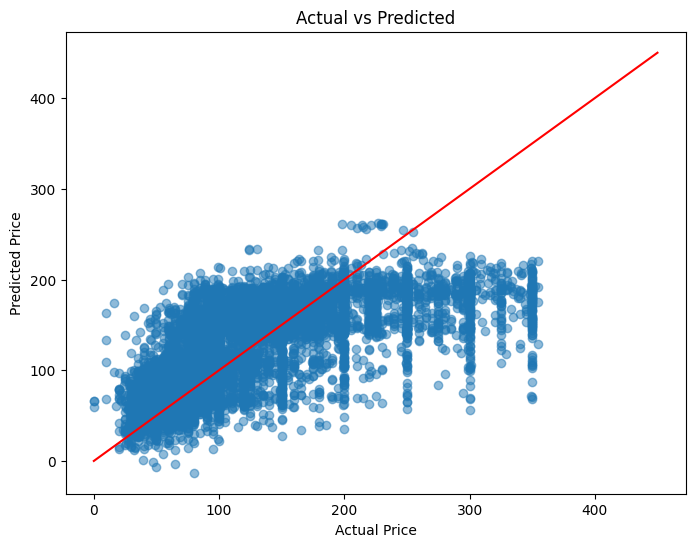

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [0,450],
    [0,450],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

In [46]:
residuals = y_test - y_pred

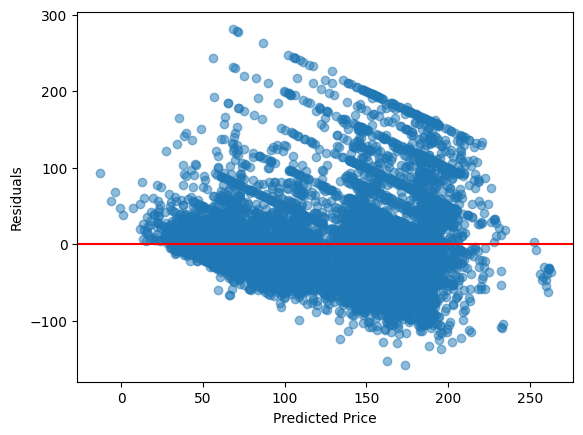

In [47]:
plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.show()

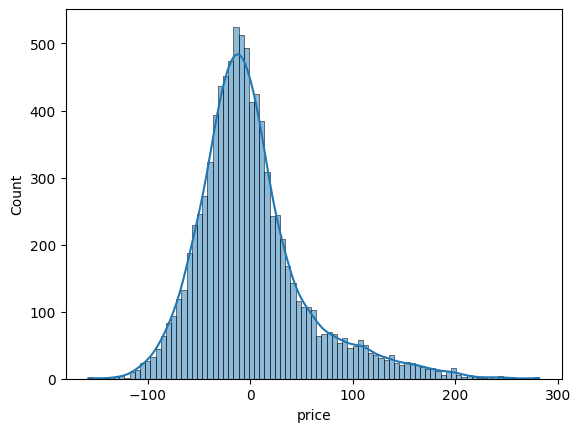

In [48]:
sns.histplot(
    residuals,
    kde=True
)

plt.show()

In [49]:
print("R2 Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("RMSE     :", round(rmse,2))

R2 Score : 0.4708
MAE      : 38.54
RMSE     : 53.24


In [50]:
comparison["Error"] = abs(
    comparison["Actual"] -
    comparison["Predicted"]
)

comparison.head()

,Actual,Predicted,Error
15403,132,173.319992,41.319992
25339,250,157.350885,92.649115
17177,350,173.114638,176.885362
39544,250,182.657475,67.342525
16658,199,186.310116,12.689884


In [51]:
comparison.sort_values(
    by="Actual"
).head()

,Actual,Predicted,Error
25796,0,66.025572,66.025572
25795,0,66.422862,66.422862
25634,0,59.424859,59.424859
32810,10,162.889792,152.889792
22835,10,133.752391,123.752391


In [52]:
comparison.sort_values(
    by="Actual"
).head()

,Actual,Predicted,Error
25796,0,66.025572,66.025572
25795,0,66.422862,66.422862
25634,0,59.424859,59.424859
32810,10,162.889792,152.889792
22835,10,133.752391,123.752391


In [53]:
comparison.sort_values(
    by="Actual",
    ascending=False
).head()

,Actual,Predicted,Error
21553,355,174.918129,180.081871
41100,355,129.010274,225.989726
43560,355,220.920383,134.079617
36155,355,192.215872,162.784128
43811,352,193.084159,158.915841


In [54]:
print("---------- PROJECT SUMMARY ----------")

print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")

print(
    f"\nThe model explains approximately "
    f"{r2*100:.2f}% of the variance in Airbnb prices."
)

print(
    f"\nOn average, predictions differ from actual "
    f"prices by {mae:.2f} dollars."
)

print(
    "\nThe model generally performs better on lower-priced listings."
)

print(
    "Expensive listings are rarer and more variable,"
    " making them harder for Linear Regression to predict."
)

---------- PROJECT SUMMARY ----------
R2 Score : 0.4708
MAE      : 38.54
RMSE     : 53.24

The model explains approximately 47.08% of the variance in Airbnb prices.

On average, predictions differ from actual prices by 38.54 dollars.

The model generally performs better on lower-priced listings.
Expensive listings are rarer and more variable, making them harder for Linear Regression to predict.
